<a href="https://colab.research.google.com/github/micael-oliveira-ufam/micael-oliveira-ufam/blob/main/(Anota%C3%A7%C3%B5es_de_PIBIC_2024_2025)_Docking_e_din%C3%A2mica_molecular_na_via_VEGF%2C_agrega%C3%A7%C3%A3o_plaquet%C3%A1ria%2C_coagula%C3%A7%C3%A3o_e_angiog%C3%AAnese_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# (Anotações de Pibic 2024/2025) Docking e dinâmica molecular na via VEGF, agregação plaquetária, coagulação e angiogênese
---

**Autores:**  Micael D. L. Oliveira <sup>1</sup>, Fabiano Sousa Barbosa <sup>1</sup>, Alisson Meza, Ana Cristina, Kelson M. T. Oliveira <sup>2</sup>, Emersom Silva Lima <sup>1</sup>. \\
<sup>1</sup> Faculty of Pharmaceutical Sciences, Federal University of Amazonas, 69077-000, Manaus, Amazonas, Brazil; \\
<sup>1</sup> Department of Chemistry, Federal University of Amazonas, 69077-000, Manaus, Amazonas, Brazil. \\
*E-mail: eslima@ufam.edu.br

Notebook escrito em Novembro 12, 2024 por Micael D. L. Oliveira.



In [ ]:
#@title **Montagem do Google drive para salvar os resultados e download do pacote Conda**

print("Montando pasta no Google Drive para salvar ...")
from google.colab import drive
drive.mount('/content/drive')

print("Instalação da biblioteca Conda para o Google Colab necessária para a execução dos cálculos ...")
!pip3 install -q condacolab
import condacolab
condacolab.install()
#condacolab.install(channels=["conda-forge", "bioconda"])

import sys
sys.path.append('/usr/local/lib/python3.10/site-packages/')
print("Instalação das principais bibliotecas com sucesso.")

Montando pasta no Google Drive para salvar ...
Mounted at /content/drive
Instalação da biblioteca Conda para o Google Colab necessária para a execução dos cálculos ...
⏬ Downloading https://github.com/jaimergp/miniforge/releases/download/24.11.2-1_colab/Miniforge3-colab-24.11.2-1_colab-Linux-x86_64.sh...
📦 Installing...
📌 Adjusting configuration...
🩹 Patching environment...
⏲ Done in 0:00:14
🔁 Restarting kernel...
Instalação das principais bibliotecas com sucesso.


In [ ]:
#@title **Instalação das bibliotecas necessárias para o docking molecular**

#O código utilizado tenta tornar mais amigável a interface de instalação das bibliotecas, mas por algum motivo os comandos não consegues ser executados

%%time
import os
import subprocess

print("Instalando AutoDock Tools v.1.5.7...")
os.system("conda install -c bioconda mgltools openbabel pdbfixer") # version of OpenBabel is 3.1.1
#!conda install -c hcc adfr-suite
#!conda config --env --add channels conda-forge
#!conda install -c conda-forge openbabel # Version of OpenBabel is 3.1.1

print("Instalação da biblioteca Meeko para preparação de ligantes...")
os.system("pip3 install meeko kora py3Dmol")
os.system("pip3 install rdkit pubchempy scipy pandas openbabel")

print("Instalação das bibliotecas para visualização e download de proteínas/receptores...")
os.system("pip3 install Py3Dmol nglview requests")

print("Instalando AutoDock Vina v.1.2.5...")
os.system("pip3 install vina numpy") # versão atual do Vina v.1.2.5 (2023)
#!conda install -c conda-forge vina # Versão antiga do Vina v.1.1.2 (2011)

Instalando AutoDock Tools v.1.5.7...
Instalação da biblioteca Meeko para preparação de ligantes...
Instalação das bibliotecas para visualização e download de proteínas/receptores...
Instalando AutoDock Vina v.1.2.5...
CPU times: user 636 ms, sys: 106 ms, total: 743 ms
Wall time: 2min 39s


256

In [ ]:
!sudo apt-get install ttf-mscorefonts-installer

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  cabextract distro-info libfontenc1 libmspack0 python3-chardet
  python3-debconf python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ubuntu-advantage-tools ubuntu-pro-client
  ubuntu-pro-client-l10n ubuntu-release-upgrader-core update-manager-core
  update-notifier-common xfonts-encodings xfonts-utils zstd
Suggested packages:
  shunit2
The following NEW packages will be installed:
  cabextract distro-info libfontenc1 libmspack0 python3-chardet
  python3-debconf python3-debian python3-distro-info python3-distupgrade
  python3-update-manager python3-yaml ttf-mscorefonts-installer
  ubuntu-advantage-tools ubuntu-pro-client ubuntu-pro-client-l10n
  ubuntu-release-upgrader-core update-manager-core update-notifier-common
  xfonts-encodings xfonts-utils zstd
0 upgraded, 21 newly installed, 0 to remove an

###Preparação do receptor via Python

Inicialmente as coordenadas do sítio de ligação dos receptores estão sendo obtidas pelo AutoDock Tools. Desta forma, primeiramente houve a remoção do ligante presente na cristalografia proveniente do Protein Data Bank e depois como se fosse um "receptor", foi descoberto seu centro de massa que será justamente o sítio do receptor. Contudo, ao realizar o cálculo do centro de massa por outras ferramentas integradas ao Python, as coordenadas diferem entre si.

No momento, a etapa de preparação dos receptores e ligantes foi realizada manualmente ao invés de automatizada com scripts em Python. Vem sendo utilizado na preparação dos receptores o Schrodinger Maestro 2023-1, para adição de Hidrogênios e minimização estrutural, além do AutoDock Tools para conversão do formato .pdb para .pdbqt já atribuindo as cargar parciais.

In [ ]:
#@title **Estrutrura tridimensional do receptor VEGF receptor (PDB ID: 2XV7)**

import py3Dmol
import requests

# Define the PDB ID of the protein you want to visualize
pdb_id = "2XV7" #@param {type:"string"}


# Fetch the PDB file for the specified PDB ID
pdb_url = f"https://files.rcsb.org/download/{pdb_id}.pdb"
response = requests.get(pdb_url)

if response.status_code == 200:
    pdb_data = response.text
else:
    raise Exception(f"Failed to fetch PDB data for PDB ID {pdb_id}")

# Create a Py3Dmol view and visualize the protein structure
viewer = py3Dmol.view(width=600, height=600)
viewer.addModel(pdb_data, "pdb")

# Style the visualization (optional)
viewer.setStyle({"cartoon": {'color':'spectrum'}})
viewer.zoomTo()
viewer.show()

#Salvar arquivo .pdb...
!wget https://files.rcsb.org/download/{pdb_id.upper()}.pdb -O {pdb_id}.pdb

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [ ]:
#@title **Exclusão de ligantes, co-fatores e moléculas de água do receptor além da adição de átomos de Hidrogênio**

#!conda install pdbfixer openbabel

from pdbfixer import PDBFixer
from openmm.app import PDBFile

receptor_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Receptors' #@param {type:"string"}
receptor_pdb_name = '4JIR' #@param {type:"string"}
receptor_output_name = '4JIR_pdbfixer_python.pdb' #@param {type:"string"}

%cd {receptor_path}

fixer = PDBFixer(filename=f'{receptor_pdb_name}.pdb')
fixer.findMissingResidues()
fixer.findNonstandardResidues()
fixer.replaceNonstandardResidues()
print("Realizando a preparação do receptor com remoção das moléculas de água, ligantes e co-fatores")
fixer.removeHeterogens(False)
fixer.findMissingAtoms()
fixer.addMissingAtoms()
print("Adiconando átomos de hidrogênios no pH de 7.4")
fixer.addMissingHydrogens(7.4)
#fixer.addSolvent(fixer.topology.getUnitCellDimensions())
PDBFile.writeFile(fixer.topology, fixer.positions, open(f'{receptor_output_name}', 'w'))

print("Receptor preparado com sucesso")

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Receptors
Realizando a preparação do receptor com remoção das moléculas de água, ligantes e co-fatores
Adiconando átomos de hidrogênios no pH de 7.4
Receptor preparado com sucesso


In [ ]:
#@title **Preparação do receptor e conversão para o formato .pdbqt**

import os

receptor_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Receptor' #@param {type:"string"}
receptor_pdb_name = '5ew3_VEGF_prep_maestro' #@param {type:"string"}
%cd {receptor_path}

print("Preparando o receptor e convertendo para o formato .pdbqt")
!prepare_receptor4.py -r {receptor_pdb_name}.pdb -o {receptor_pdb_name}.pdbqt -A hydrogens -U nphs_lps -v # Using AutoDock Tools 1.5.7 rc1

print("Receptor foi preparado com sucesso!")

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Receptor
Preparando o receptor e convertendo para o formato .pdbqt
set verbose to  True
read  5ew3_VEGF_prep_maestro.pdb
setting up RPO with mode= automatic and outputfilename=  5ew3_VEGF_prep_maestro.pdbqt
charges_to_add= gasteiger
delete_single_nonstd_residues= None
adding gasteiger charges to peptide
Receptor foi preparado com sucesso!


# Descoberta das coordenadas do sítio de ligação do alvo molecular

Inicialmente as coordenadas do sítio de ligação dos receptores serão obtidas pelo AutoDock Tools. Desta forma, primeiramente houve a remoção do ligante presente na cristalografia proveniente do Protein Data Bank e depois como se fosse um "receptor", foi descoberto seu centro de massa que será justamente o sítio do receptor. Contudo, ao realizar o cálculo do centro de massa por outras ferramentas integradas ao Python, as coordenadas diferem entre si.

In [ ]:
#@title **Obtenção das coordenadas do sítio de ligação da proteína Aldose Reductase (PDB ID: 4JIR)**

print("Instalando as bibliotecas necessárias para descoberta do sítio de ligação a partir da cristalografia")
os.system("pip3 install pdbparser")
os.system("pip3 install biopython")

print("Entrando no diretório selecionado...")
ligand_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Redocking' #@param {type:"string"}
ligand_name = "4jir_only_ligand_Epalrestat.pdb" #@param {type:"string"}
%cd {ligand_path}

from Bio.PDB import PDBParser

parser = PDBParser()
structure = parser.get_structure('foo', f'{ligand_name}')
com = structure.center_of_mass()

# For each chain
print("\n As coordenadas do sítio de ligação foram: ")
for chain in structure.get_chains():
    binding_site = chain.center_of_mass()
    print(chain.center_of_mass())

Instalando as bibliotecas necessárias para descoberta do sítio de ligação a partir da cristalografia
Entrando no diretório selecionado...
/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Redocking

 As coordenadas do sítio de ligação foram: 
[-5.862404  7.862499 17.630215]


# Preparação dos ligantes via Python

In [ ]:
!pip3 install rdkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.9/34.9 MB 21.1 MB/s eta 0:00:00


/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas


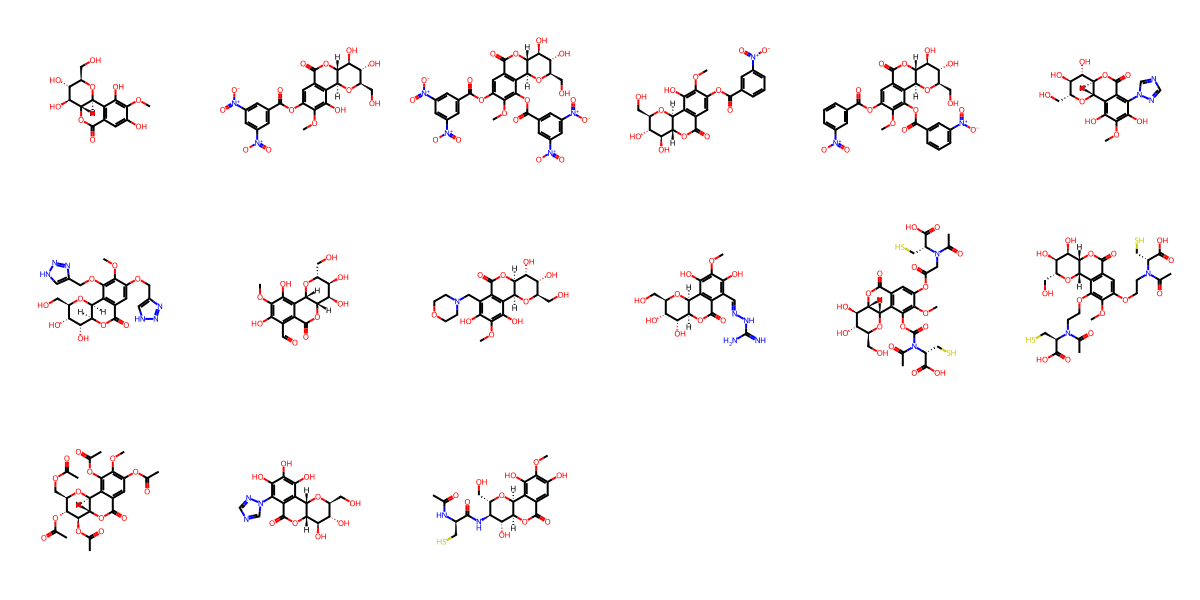

In [ ]:
#@title **Derivados da bergenina propostos e sintetizados por Dra. Ana Cristina**


from rdkit import Chem
from rdkit.Chem import rdBase
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit import RDConfig
import os

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas

mol2 = Chem.SDMolSupplier("derivates_bergenin_2d.sdf")
mols = [m for m in mol2 ]
img = Draw.MolsToGridImage(mols, molsPerRow=6, useSVG=True)
img

Instalando bibliotecas de visualização estrutural química...
Gerando a estrutura 2D...


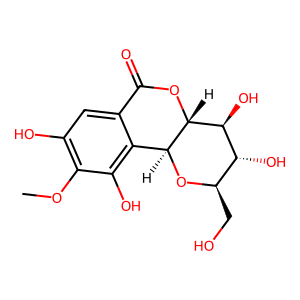

In [ ]:
#@title **Download da molécula 2D na base de dados PubChem e visualização de sua estrutura plana**
import os

print("Instalando bibliotecas de visualização estrutural química...")
os.system("pip3 install rdkit pubchempy")
print("Gerando a estrutura 2D...")
import pubchempy as pcp

molecule_name = "bergenin" #@param {type:"string"}

results = pcp.get_compounds(molecule_name, 'name')
for compound in results:
  smiles = compound.isomeric_smiles

from rdkit import Chem
from rdkit.Chem import Draw
m = Chem.MolFromSmiles(smiles)
Draw.MolToImage(m)

In [ ]:
#@title **Geração da estrutura tridimensional da molécula escolhida anteriormente**

import kora.install.rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import py3Dmol

molecule_name = "bergenin" #@param {type:"string"}
result_file_path = "/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Ligands" #@param {type:"string"}
%cd {result_file_path}

def convert(smi, style='stick'):
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=30000)
    mblock = Chem.MolToMolBlock(mol)

    # Convert the Mol block to an RDKit molecule
    mol = Chem.MolFromMolBlock(mblock)

    # Save the molecule to a .mol2 file
    mol2_filename = f"""{molecule_name}_3d_rdkit_MMFF94.mol2"""
    Chem.MolToMolFile(mol, mol2_filename)
    print("A estrutura tridimensional da molécula escolhida foi salva com sucesso em .mol2")

    view = py3Dmol.view(width=400, height=400)
    view.addModel(mblock, 'mol')
    view.setStyle({style:{}})
    view.zoomTo()
    view.show()


# Conversão do código smiles para a estrutura tridimensional da molécula obtimizada com o campo de força MMFF94
convert(smiles)


/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Ligands
A estrutura tridimensional da molécula escolhida foi salva com sucesso em .mol2


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [ ]:
%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória
!obabel Evolutionary_Library_bergenin.sdf -O Evolutionary_Library_bergenin.mol2 --gen3d best -p 7.4 --canonical

Caso seja uma molécula nova é preciso utilizar um software para desenho de estruturas químicas como o ACD ChemSketch (gratuito para fins acadêmicos),Perkin Elmer ChemDraw (pago) ou MarvinSketch (gratuito para fins acadêmicos). Depois, basta selecionar a respectiva estrutura e copiar como um código SMILES, que é uma representação computacional para visualização de moléculas.

MarvinJS: https://marvinjs-demo.chemaxon.com/latest/demo.html \\
*Obs.: É uma versão mais simples e portanto com menos recursos do que o MarvinSketch, mas que roda diretamente no navegador sem a necessidade da instalação do software.* \\

Perkin Elmer ChemDraw: https://drive.google.com/file/d/1VxrOm41_oONNMInfsWt1pMQ6G8_r7PI4/view?usp=sharing \\

MarvinSketch: https://download.chemaxon.com/marvin \\

ACD ChemSketch: https://www.acdlabs.com/resources/free-chemistry-software-apps/chemsketch-freeware/

##Pular esta etapa caso tenha encontrado com sucesso a molécula submetida anteriormente

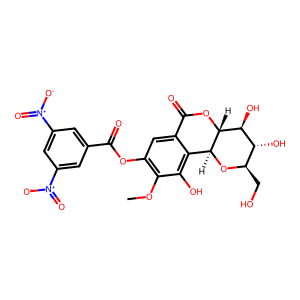

In [ ]:
#@title **Construção da molécula 2D a partir do código SMILES fornecido**

os.system("pip3 install rdkit scipy pandas")

codigo_SMILES = "COC1=C(OC(C2=CC([N+]([O-])=O)=CC([N+]([O-])=O)=C2)=O)C=C3C([C@H]4[C@H](OC3=O)[C@@H](O)[C@H](O)[C@@H](CO)O4)=C1O" #@param {type:"string"}

from rdkit import Chem
from rdkit.Chem import Draw
m = Chem.MolFromSmiles(codigo_SMILES)
Draw.MolToImage(m)

In [ ]:
#@title **Geração da estrutura tridimensional da molécula escolhida anteriormente**

import kora.install.rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
import py3Dmol

def show(smi, style='stick'):
    mol = Chem.MolFromSmiles(smi)
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol, maxIters=20000)
    mblock = Chem.MolToMolBlock(mol)

    view = py3Dmol.view(width=400, height=400)
    view.addModel(mblock, 'mol')
    view.setStyle({style:{}})
    view.zoomTo()
    view.show()

# example
show(codigo_SMILES)  # or 'P'

You appear to be running in JupyterLab (or JavaScript failed to load for some other reason). You need to install the 3dmol extension: 
 jupyter labextension install jupyterlab_3dmol

In [ ]:
#@title **Conversão entre formatos químicos (.mol2, .pdbqt, .sdf, dentre outros...)**

ligand_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Ligands' #@param {type:"string"}
%cd {ligand_path}

ligand_name = 'lipoic_acid_pubchem' #@param {type:"string"}


!obabel -isdf {ligand_name}.sdf -omol2 -O {ligand_name}.mol2

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Ligands
1 molecule converted


In [ ]:
#@title **Preparação e conversão do ligante para o formato .pdbqt necessário para o docking molecular usando o algoritmo AutoDock Tools 1.5.7**

ligand_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Ligands' #@param {type:"string"}
%cd {ligand_path}

ligand_name = "lipoic_acid_pubchem" #@param {type:"string"}

!prepare_ligand4.py -l {ligand_name}.mol2 -o {ligand_name}.pdbqt -U nphs_lps -v

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Ligands
set verbose to  True
read  lipoic_acid_pubchem.mol2
setting up LPO with mode= automatic and outputfilename=  lipoic_acid_pubchem.pdbqt
and check_for_fragments= False
and bonds_to_inactivate= 
returning  0
No change in atomic coordinates


In [ ]:
#@title **Preparação e conversão de vários ligantes de uma única vez para o formato .pdbqt**

ligand_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular' #@param {type:"string"}
%cd {ligand_path}

!prepare_ligand4.py -l *.mol2 -o *.pdbqt -U nphs_lps -v
#!prepare_ligand4.py -l Evolutionary_Library_bergenin.mol2 -o Evolutionary_Library_bergenin.pdbqt -U nphs_lps -v


/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular


In [ ]:
%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Multiple ligands
!obabel *.mol2 -opdbqt -m --gen3d best -p

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular/Multiple ligands
*** Open Babel Warning  in CheckForUnintendedBatch
  This was a batch operation. For splitting, use non-empty base name for the output files
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Compound 2)
  with Atom Ids as follows: 4
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Compound 2)
  with Atom Ids as follows: 4
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Compound 2)
  with Atom Ids as follows: 4
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Compound 3)
  with Atom Ids as follows: 4
*** Open Babel Warning  in CorrectStereoAtoms
  Could not correct 1 stereocenter(s) in this molecule (Compound 3)
  with Atom Ids as follows: 4
*** Open Babel Warning  in CorrectStereoA

In [ ]:
!wget -q https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_split_1.2.5_linux_x86_64
!chmod +x vina_split_1.2.5_linux_x86_64

!./vina_split_1.2.5_linux_x86_64 --input 3d_combinatorial_library_data_warrior.pdbqt

AutoDock Vina PDBQT Split v1.2.5
Prefix for ligands will be 3d_combinatorial_library_data_warrior_ligand_
Prefix for flexible side chains will be 3d_combinatorial_library_data_warrior_flex_


In [ ]:
!pip3 install rdkit scipy pandas numpy

### Utilização do pacote Meeko para preparação automatizada de ligantes

In [ ]:
#conda activate vina
#conda install python=3.9.7 # not strictly needed but prevents RDKit incompatibility
#conda install -c conda-forge numpy openbabel scipy rdkit
#pip install meeko

!pip3 install numpy scipy rdkit meeko pandas

  Using cached scipy-1.13.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (60 kB)
  Using cached rdkit-2023.9.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (3.9 kB)
  Using cached pandas-2.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (19 kB)
  Using cached pillow-10.3.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
  Using cached pytz-2024.1-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2024.1-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached scipy-1.13.1-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (38.6 MB)
Using cached rdkit-2023.9.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (34.9 MB)
Using cached pandas-2.2.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (13.0 MB)
Using cached pytz-2024.1-py2.py3-none-any.whl (505 kB)
Using cached tzdata-2024.1-py2.py3-none-any.whl (345 kB)
Using cached pillow-10.3.0-cp310-cp310-manylinux_2_28_x86_64.whl (4.

In [ ]:
!pip3 install numpy scipy rdkit meeko pandas

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular

!mk_prepare_ligand.py -i *.mol2 -o *.pdbqt

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular
usage: mk_prepare_ligand.py [-h] [-v] -i INPUT_MOLECULE_FILENAME [--name_from_prop NAME_FROM_PROP]
                            [-o OUTPUT_PDBQT_FILENAME] [--multimol_outdir MULTIMOL_OUTPUT_DIR]
                            [--multimol_prefix MULTIMOL_PREFIX] [-z]
                            [--multimol_targz_size MULTIMOL_TARGZ_SIZE] [-] [-c CONFIG_FILE]
                            [--rigid_macrocycles] [--macrocycle_allow_A] [--keep_chorded_rings]
                            [--keep_equivalent_rings] [--min_ring_size MIN_RING_SIZE] [-w]
                            [--merge_these_atom_types [MERGE_THESE_ATOM_TYPES ...]] [-r SMARTS]
                            [-b i j [i j ...]] [-a] [-p LOAD_ATOM_PARAMS [LOAD_ATOM_PARAMS ...]]
                            [-aa [{'smarts': '<smarts pattern>', 'atype': ',atomtype name>'}, {'smarts': '<smarts pattern>', 'atype': ',atomtype name>'}]]
                            

# Construção de arquivo de configuração no docking molecular

In [ ]:
#@title **Geração do arquivo de configuração necessário para o docking molecular**

ligand_path = "/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Ligands" #@param {type:"string"}
ligand_name = "Epalrestat.pdbqt" #@param {type:"string"}
receptor_path = "/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Receptors" #@param {type:"string"}
receptor_name = "7pp1_prep_maestro.pdbqt" #@param {type:"string"}

grid_box_center_x = "-22.418  " #@param {type:"string"}
grid_box_center_y = "26.560" #@param {type:"string"}
grid_box_center_z = "27.154" #@param {type:"string"}

grid_box_size_x = "21.322 "  #@param {type:"string"}
grid_box_size_y = "36.868" #@param {type:"string"}
grid_box_size_z = "33.776" #@param {type:"string"}

print("Grid box center x:", grid_box_center_x)

exhaustiveness = "96" #@param {type:"string"}
docking_results_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with P2Y12 (PDB ID 7PP1)' #@param {type:"string"}
%cd {docking_results_path}
docking_results_name = 'result_docking1_7pp1_P2Y12_Epalrestat' #@param {type:"string"}
config_file_name = 'config_rigid_7pp1_P2Y12_docking.txt' #@param {type:"string"}

# Define the text content
text_content = f"""receptor = {receptor_path}/{receptor_name}
ligand = {ligand_path}/{ligand_name}
center_x = {grid_box_center_x}
center_y = {grid_box_center_y}
center_z = {grid_box_center_z}
size_x = {grid_box_size_x}
size_y = {grid_box_size_y}
size_z = {grid_box_size_z}
out = {docking_results_name}.pdbqt
exhaustiveness = {exhaustiveness}
"""

# Specify the file name
file_name = f"{config_file_name}"

# Open the file in write mode and write the content
with open(file_name, "w") as file:
    file.write(text_content)

print(f"O arquivo '{file_name}' foi criado e salvo com sucesso.")


Grid box center x: -22.418  
/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with P2Y12 (PDB ID 7PP1)
O arquivo 'config_rigid_7pp1_P2Y12_docking.txt' foi criado e salvo com sucesso.


# Realização das simulações de docking molecular com o AutoDock Vina v.1.2.5

Para cada complexo proteína-ligante é executado o script de docking abaixo. Se for considerado a flexibilidade parcial do receptor, basta colocar o nome do arquivo .pdbqt flexível ao lado do nome para a estrutura rígida. Mesmo o algoritmo limitando para

In [ ]:
#@title **Download do algoritmo AutoDock Vina v.1.2.5**


#Download and extract Autodock Vina from SCRIPPS
#Then, we set up an alias for vina to be treated as a native binary
docking_calculations_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular' #@param {type:"string"}
%cd {docking_calculations_path}

print("Baixando executável do AutoDock Vina v.1.2.5...")
!wget -q https://github.com/ccsb-scripps/AutoDock-Vina/releases/download/v1.2.5/vina_1.2.5_linux_x86_64
!chmod +x vina_1.2.5_linux_x86_64
print("Instalação do AutoDock Vina v.1.2.5 feita com sucesso.")

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular
Baixando executável do AutoDock Vina v.1.2.5...
Instalação do AutoDock Vina v.1.2.5 feita com sucesso.


In [ ]:
#@title **Execução do docking molecular a partir do ligante e receptor descritos nas etapas anteriores**

config_file_name = 'config_4ntj_bergenin.txt' #@param {type:"string"}

print("Realizando o docking molecular...")
!./vina_1.2.5_linux_x86_64 --config {config_file_name}

Realizando o docking molecular...
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#                                                               #
# Please see https://

In [ ]:
#@title **Execução do docking molecular para o receptor P38 MAPK**

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking calculations/AutoDock Vina (v.1.2.5)
config_file_name = 'config_1ouk_P38_MAPK_docking.txt' #@param {type:"string"}

print("Realizando o docking molecular...")
!./vina_1.2.5_linux_x86_64 --config {config_file_name}

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking calculations/AutoDock Vina (v.1.2.5)
Realizando o docking molecular...
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.213

In [ ]:
vina --config config.txt --batch ligands_dir/*.pdbqt

In [ ]:
#@title **Execução do docking molecular em larga escala**

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular
config_file_name = 'config_8XJN_TXAII_virtual_screening.txt' #@param {type:"string"}

print("Realizando o docking molecular...")
!./vina_1.2.5_linux_x86_64 --config {config_file_name} --batch Multiple_ligands/*.pdbqt --dir Screening_results

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Docking molecular
Realizando o docking molecular...
AutoDock Vina v1.2.5
#################################################################
# If you used AutoDock Vina in your work, please cite:          #
#                                                               #
# J. Eberhardt, D. Santos-Martins, A. F. Tillack, and S. Forli  #
# AutoDock Vina 1.2.0: New Docking Methods, Expanded Force      #
# Field, and Python Bindings, J. Chem. Inf. Model. (2021)       #
# DOI 10.1021/acs.jcim.1c00203                                  #
#                                                               #
# O. Trott, A. J. Olson,                                        #
# AutoDock Vina: improving the speed and accuracy of docking    #
# with a new scoring function, efficient optimization and       #
# multithreading, J. Comp. Chem. (2010)                         #
# DOI 10.1002/jcc.21334                                         #
#     

# Analisando os resultados obtidos pelo docking molecular

É importante que os resultados sejam convertidos primeiramente para .mol2, para evitar que haja distorções na estrutura do ligante.

In [ ]:
#@title **Conversão do resultado de .pdbqt para .mol2**

#We need to convert our Autodock Vina results from pdbqt into pdb
#For this, we use babel
docking_results_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação/Docking com beta-CD' #@param {type:"string"}
%cd {docking_results_path}

result_file = "docking2_hp_beta_cd_bergenin_dft_6_311g" #@param {type:"string"}

!obabel -ipdbqt {result_file}.pdbqt -omol2 -O {result_file}.mol2 -p --title {result_file}


/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação/Docking com beta-CD
9 molecules converted


In [ ]:
#@title **Conversão do resultado de .mol2 para .pdb**

#We need to convert our Autodock Vina results from pdbqt into pdb
#For this, we use babel
docking_results_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with Aldolase/Docking results' #@param {type:"string"}
%cd {docking_results_path}

result_file = "result_redocking1_4jir_Aldolase_only_ligand_Epalrestat" #@param {type:"string"}

!obabel -imol2 {result_file}.mol2 -opdb -O {result_file}.pdb -p --unique --title {result_file}


/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with Aldolase/Docking results
*** Open Babel Warning  in InChI code
  result_redocking1_4jir_Aldolase_only_ligand_Epalrestat :Ambiguous stereo: center(s)
1 molecule converted


In [ ]:
#@title **Conversão do resultado de .pdbqt para .pdb**

#We need to convert our Autodock Vina results from pdbqt into pdb
#For this, we use babel
docking_results_path = '/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação/Docking com beta-CD/' #@param {type:"string"}
%cd {docking_results_path}

result_file = "docking2_hp_beta_cd_bergenin_dft_6_311g" #@param {type:"string"}

!obabel -ipdbqt {result_file}.pdbqt -opdb -O {result_file}.pdb -p --title {result_file}


/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação/Docking com beta-CD
9 molecules converted


In [ ]:
#@title **União do complexo proteína-ligante final a partir do resultado de docking**

!pip3 install parmed
import parmed as pmd

ligand_file = "result_docking1_4jir_Aldolase_derivate_acd72"        #@param {type:"string"}
receptor_pdb_file = "4jir_aldolase_prepared_maestro.pdb"    #@param {type:"string"}
output_pdb_file = "complex_result_docking1_4jir_Aldolase_derivate_acd72.pdb"  #@param {type:"string"}

#!obabel -imol2 {result_file}.mol2 -opdb -O {result_file}.pdb -p --unique --title {result_file}

print("Unindo o complexo proteína-ligante...")
pdb1 = pmd.load_file(f"{ligand_file}.pdb")
pdb2 = pmd.load_file(f"{receptor_pdb_file}")

combined = pdb1 + pdb2
combined.save(f"{output_pdb_file}")
print("O complexo foi salvo com sucesso!")

Unindo o complexo proteína-ligante...
O complexo foi salvo com sucesso!


In [ ]:
#@title **Visualização do ligante ancorado no sítio da proteína**

docking_results_path = "/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with Aldolase" #@param {type:"string"}
%cd {docking_results_path}

ligand_pdb_file = "result_docking1_4jir_Aldolase_bergenin_dft_6_311G.pdb"        #@param {type:"string"}
receptor_pdb_file = "4jir_aldolase_prepared_maestro.pdb"    #@param {type:"string"}

!pip3 install py3Dmol
import py3Dmol
v = py3Dmol.view()
v.addModel(open(f'{receptor_pdb_file}').read())
v.setStyle({'model':0},{'cartoon':{}})
v.addModel(open(f'{ligand_pdb_file}').read())
v.setStyle({'model':1},{'stick':{'colorscheme':'greenCarbon','radius':.125}})
v.addModelsAsFrames(open(f'{receptor_pdb_file}').read())
v.animate({'interval':1000})
v.zoomTo({'model':1})
v.rotate(90)

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/AutoDock Vina (v.1.2.5)/Docking with Aldolase


3Dmol.js failed to load for some reason. Please check your browser console for error messages.

Interação entre o receptor Aldolase Reductase e a conformação obtida no docking molecular com a bergenina

# Triagem virtual automatizada usando AutoDock Vina v.1.2.5

In [ ]:
# vina_screen_local.sh
#! /bin/bash

for f in ligand_*.pdbqt; do
    b=`basename $f .pdbqt`
    echo Processing ligand $b
    mkdir -p $b
    vina --config conf.txt --ligand $f --out ${b}/out.pdbqt --log ${b}/log.txt
done

SyntaxError: invalid syntax (<ipython-input-1-4f5840c3ef72>, line 4)

In [ ]:
!vina --config config.txt --batch ligands_dir/*.pdbqt


/bin/bash: line 1: vina: command not found


In [ ]:
# @title **Run AutoDock Vina**
# @markdown Select **< Exhaustiveness >** for molecular docking. **[ Default is 16 ]** \
# @markdown This generates a **`output.pdbqt`** containing different binding
# @markdown poses predicted for each docked ligand.

Exhaustiveness = '32' # @param [4, 8, 16, 32, 64, 128, 256]

cpu_cores = os.cpu_count()
LIG_dFLDs = sorted(folder[:-1] for folder in glob.glob(DCK_FLD + '/*/'))

# -- Start screening --
start = time.time()
count = 0
for folder in tqdm(LIG_dFLDs):
    LIG_ID = os.path.basename(folder)
    LIG_pdbqt = LIG_ID + '.pdbqt'
    LIG_oupt_log = LIG_ID + '_output.log'
    LIG_oupt_pdbqt = LIG_ID + '_output.pdbqt'
    LIG_dFLD = os.path.join(DCK_FLD, LIG_ID)
    LIG_pdbqt_dFFile = os.path.join(LIG_dFLD, LIG_pdbqt)
    LIG_oupt_log_dFFile = os.path.join(LIG_dFLD, LIG_oupt_log)
    LIG_oupt_pdbqt_dFFile = os.path.join(LIG_dFLD, LIG_oupt_pdbqt)

    %vina --receptor {PROT_pdbqt_dFile} --ligand {LIG_pdbqt_dFFile} \
    --out {LIG_oupt_pdbqt_dFFile} --config {cfg_dFile} --cpu {cpu_cores} \
    --exhaustiveness {Exhaustiveness} --verbosity 2 &> {LIG_oupt_log_dFFile}

    count += 1
end = time.time()
# -- End screening --

print(f'')
print(f'+ Screening completed')
print(f'+ Time elapsed: ' + time.strftime('%Mm %Ss', time.gmtime(end - start)))
print(f'+ {count} ligand_output.pdbqt > DOCKING folder')

# Análise gráfica dos resultados de docking molecular

In [ ]:
#@title **Visualização em tabelas dos dados de afinidade para os diferentes derivados da bergeninas analisados**

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Docking analysis

import pandas as pd

dados = pd.read_csv("Docking_valores_afinidade_16_07_2024.csv")
dados

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Docking molecular/Docking analysis


,Substancia,P2Y12,P2X3,P38_MAPK,Sorbitol_desidrogenase,Aldolase_reductase
0,Composto de referência (AZD1283),-10.200,-6.328,-7.937,-8.282,-9.154
1,Composto de referência (Clopidogrel),-6.758,-6.080,-7.251,-7.163,-6.696
2,Composto de referência (Selatogrel),-9.049,-7.467,-8.789,-8.366,-8.770
3,Composto de referência (Sorbinil),-7.647,-6.570,-7.370,-7.917,-7.105
4,Composto de referência (Tolrestat),-7.624,-6.190,-7.815,-7.211,-7.466
5,Composto de referência (Zenarestat),-7.677,-7.693,-8.691,-8.146,-8.443
6,Composto de referência (Ácido acetilsalicí­lico),-6.149,-5.322,-5.991,-5.762,-5.893
7,Bergenina,-7.126,-7.450,-7.521,-7.547,-7.062
8,Triazol bergenina,-7.080,-7.188,-7.818,-7.415,-7.039
9,Acetato de bergenina,-6.611,-7.122,-7.667,-8.246,-7.625


# Outras ferramentas importantes na bioinformática

In [ ]:
#@title **Unir vários arquivos de um mesmo formato químico num único apenas**
%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas/mol2
!cat *.sdf > bergenin_derivates_docking.sdf

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas/mol2


In [ ]:
#@title **Conversão entre formatos químicos (.mol2, .pdbqt, .sdf, dentre outros...)**

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas
!obabel -ismi all_derivates_bergenin.smiles -osdf -O all_derivates_bergenin.sdf

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Estruturas químicas
*** Open Babel Warning  in WriteMolecule
  No 2D or 3D coordinates exist. Stereochemical information will be stored using an Open Babel extension. To generate 2D or 3D coordinates instead use --gen2D or --gen3D.
15 molecules converted


In [ ]:
#@title **Geração de confôrmero 3D e conversão para .mol2**
%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória
!obabel -imol2 maestro_enumeration_nitrobenzene_derivates_bergenin.mol2 -osdf -O maestro_enumeration_nitrobenzene_derivates_bergenin_3d.sdf --gen3D

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
*** Open Babel Error  in Do
  3D coordinate generation failed
100 molecules converted


#Simulações de dinâmica molecular

Na preparação da topologia do ligante pelo CGenFF é fundamental que todos os átomos de Hidrogênios tenham sido adicionados explicitamente. Isso por ser feito com do Chimera, por exmeplo.

Outro detalhe muito importante, é construir o complexo proteína-ligante novamente pelo Maestro, mas agora usando o ligante em .mol2 retornado pelo CGenFF. Apenas desta forma, o QwikMD não irá acusar que existem diferenças na indicação de cada átomo ou conectividade entre os .mol2.

In [ ]:
!wget https://www.ks.uiuc.edu/Research/namd/3.0b3/download/897501/NAMD_3.0b3_Linux-x86_64-multicore-CUDA.tar.gz -p /content/drive/MyDrive/Molecular dynamics

--2023-09-26 18:00:25--  https://www.ks.uiuc.edu/Research/namd/3.0b3/download/897501/NAMD_3.0b3_Linux-x86_64-multicore-CUDA.tar.gz
Resolving www.ks.uiuc.edu (www.ks.uiuc.edu)... 130.126.120.43
Connecting to www.ks.uiuc.edu (www.ks.uiuc.edu)|130.126.120.43|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 242465080 (231M) [application/x-gzip]
Saving to: ‘www.ks.uiuc.edu/Research/namd/3.0b3/download/897501/NAMD_3.0b3_Linux-x86_64-multicore-CUDA.tar.gz’

www.ks.uiuc.edu/Res 100%[===================>] 231.23M  91.0MB/s    in 2.5s    

2023-09-26 18:00:31 (91.0 MB/s) - ‘www.ks.uiuc.edu/Research/namd/3.0b3/download/897501/NAMD_3.0b3_Linux-x86_64-multicore-CUDA.tar.gz’ saved [242465080/242465080]

/content/drive/MyDrive/Molecular: Scheme missing.
--2023-09-26 18:00:31--  http://dynamics/
Resolving dynamics (dynamics)... failed: Name or service not known.
wget: unable to resolve host address ‘dynamics’
FINISHED --2023-09-26 18:00:31--
Total wall clock time: 5.6s
Downloa

In [ ]:
#

### Nanoencapsulamento da Bergenina por beta-ciclodextrina

Instalando bibliotecas de visualização estrutural química...
Gerando a estrutura 2D...


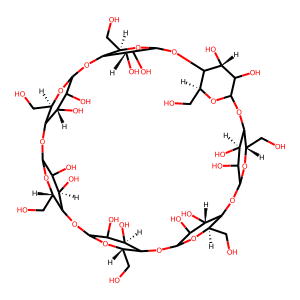

In [ ]:
#@title **Download da estrutura 2D da beta-ciclodextrina ($\beta$-CD)**
import os

print("Instalando bibliotecas de visualização estrutural química...")
os.system("pip3 install rdkit pubchempy")
print("Gerando a estrutura 2D...")
import pubchempy as pcp

molecule_name = "beta-cyclodextrin" #@param {type:"string"}

results = pcp.get_compounds(molecule_name, 'name')
for compound in results:
  smiles_pubchem = compound.isomeric_smiles

from rdkit import Chem
from rdkit.Chem import Draw
m = Chem.MolFromSmiles(smiles_pubchem)
Draw.MolToImage(m)

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação


<ipython-input-4-f548cd1107bd>:13: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


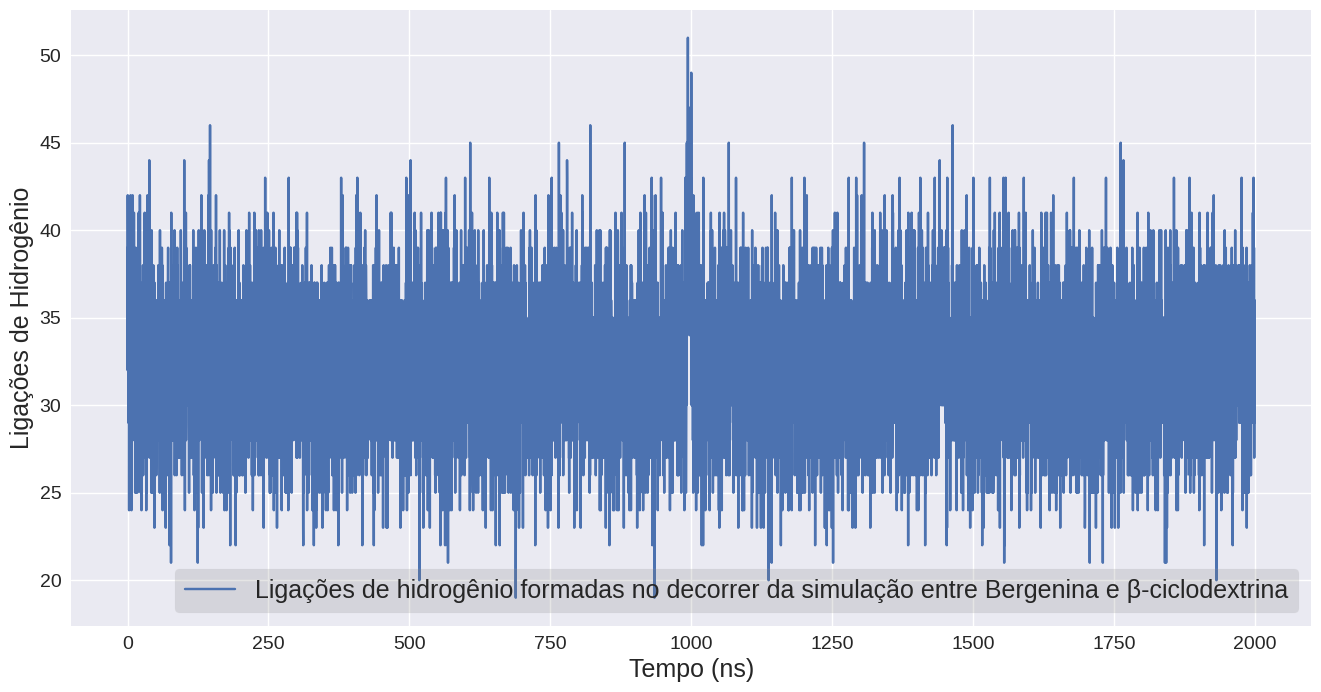

In [ ]:
#@title **Formação de ligações de Hidrogênios ao decorrer da simulação**
import matplotlib.pyplot as plt
import pandas as pd

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação

d1 = pd.read_csv('hydrogen_bonds_interactions_md_100ns_beta_cyclodextrin_bergenin_dft_6_311g.csv', decimal='.')

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('seaborn')

fig = plt.figure(figsize=(16,8))
ax = plt.subplot(111)
#ax.set_xticks(np.arange(150, 420, 20))
#ax.set_yticks(np.arange(0, 1, 0.10))
#ax.grid(which='major', color='#CCCCCC', linestyle='--')
#ax.grid(which='minor', color='#CCCCCC', linestyle='--')
#plt.ylim([0, 1])
plt.plot(d1['Time (ns)'], d1['Hydrogen Bonds'], label='Ligações de hidrogênio formadas no decorrer da simulação entre Bergenina e β-ciclodextrina')

# A conversão de epsilon para absorbância requer o uso da Lei de Beer-Lambert, onde A = epsilon (M^{-1} . cm^-1) * l (cm) * c (mol/L)

plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel('Ligações de Hidrogênio', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(facecolor="gray", framealpha=0.2, frameon=True, fontsize=18, loc=4)
plt.savefig('hbond_md_2000ns_beta_cyclodextrin_bergenin.png', dpi=300, bbox_inches = 'tight')

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação


<ipython-input-3-6c050865c04e>:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


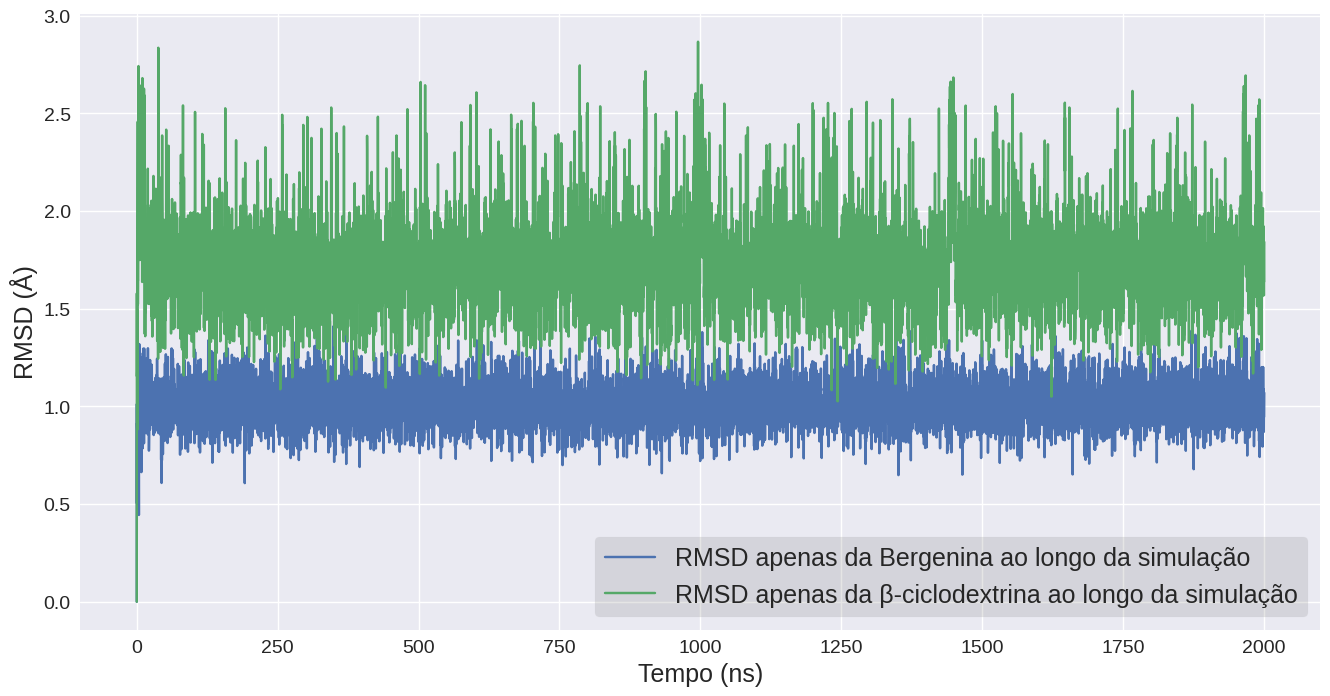

In [ ]:
#@title **Formação de ligações de Hidrogênios ao decorrer da simulação**
import matplotlib.pyplot as plt
import pandas as pd

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação

d1 = pd.read_csv('rmsd_only_bergenin_md_100ns_beta_cyclodextrin.csv', decimal='.')
d2 = pd.read_csv('rmsd_only_nanoformulation_md_100ns_beta_cyclodextrin_bergenin_dft_6_311g.csv', decimal='.')

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('seaborn')

fig = plt.figure(figsize=(16,8))
ax = plt.subplot(111)
#ax.set_xticks(np.arange(150, 420, 20))
#ax.set_yticks(np.arange(0, 1, 0.10))
#ax.grid(which='major', color='#CCCCCC', linestyle='--')
#ax.grid(which='minor', color='#CCCCCC', linestyle='--')
#plt.ylim([0, 1])
plt.plot(d1['Time (ns)'], d1['RMSD'], label='RMSD apenas da Bergenina ao longo da simulação')
plt.plot(d2['Time (ns)'], d2['RMSD'], label='RMSD apenas da β-ciclodextrina ao longo da simulação')

# A conversão de epsilon para absorbância requer o uso da Lei de Beer-Lambert, onde A = epsilon (M^{-1} . cm^-1) * l (cm) * c (mol/L)

plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel('RMSD (Å)', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(facecolor="gray", framealpha=0.2, frameon=True, fontsize=18, loc=4)
plt.savefig('rmsd_md_2000ns_beta_cyclodextrin_bergenin.png', dpi=300, bbox_inches = 'tight')

/content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação


<ipython-input-6-3d5c2ef75732>:14: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


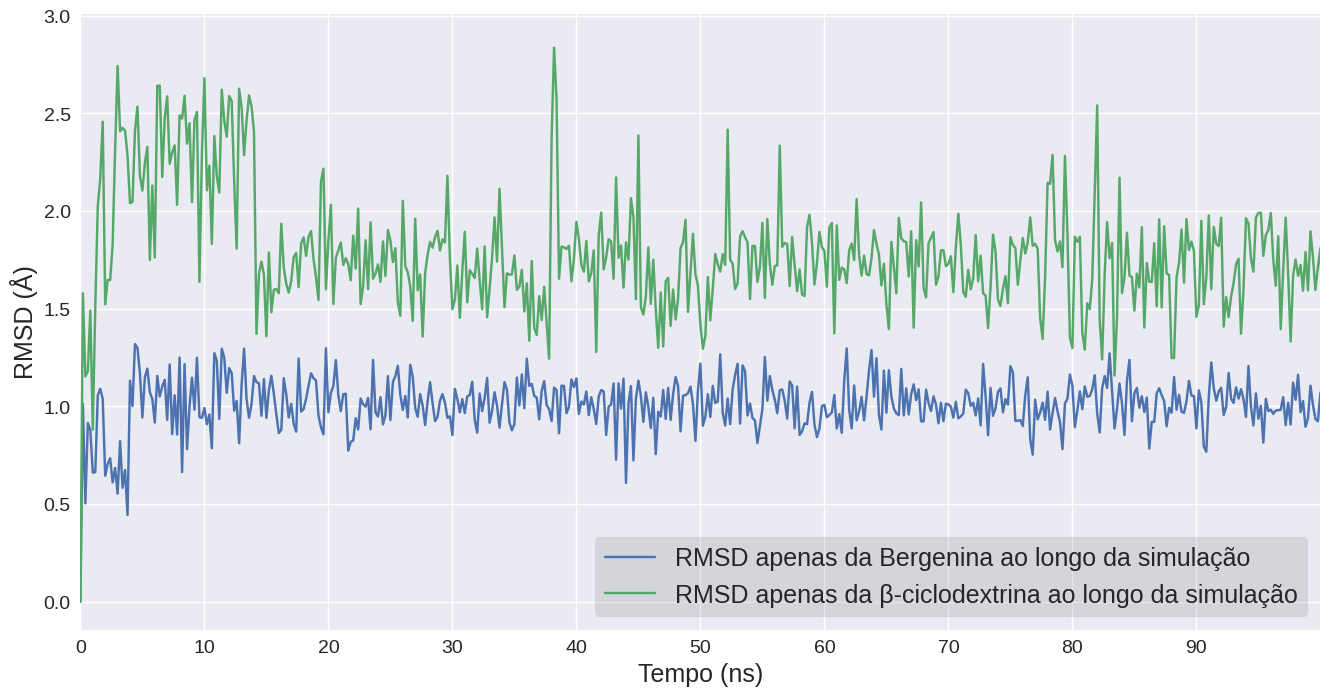

In [ ]:
#@title **Formação de ligações de Hidrogênios ao decorrer da simulação**
import matplotlib.pyplot as plt
import pandas as pd

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2024-2025/Nanoformulação

d1 = pd.read_csv('rmsd_only_bergenin_md_100ns_beta_cyclodextrin.csv', decimal='.')
d2 = pd.read_csv('rmsd_only_nanoformulation_md_100ns_beta_cyclodextrin_bergenin_dft_6_311g.csv', decimal='.')

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('seaborn')

fig = plt.figure(figsize=(16,8))
ax = plt.subplot(111)
ax.set_xticks(np.arange(0, 100, 10))
#ax.set_yticks(np.arange(0, 1, 0.10))
#ax.grid(which='major', color='#CCCCCC', linestyle='--')
#ax.grid(which='minor', color='#CCCCCC', linestyle='--')
plt.xlim([0, 100])
plt.plot(d1['Time (ns)'], d1['RMSD'], label='RMSD apenas da Bergenina ao longo da simulação')
plt.plot(d2['Time (ns)'], d2['RMSD'], label='RMSD apenas da β-ciclodextrina ao longo da simulação')

# A conversão de epsilon para absorbância requer o uso da Lei de Beer-Lambert, onde A = epsilon (M^{-1} . cm^-1) * l (cm) * c (mol/L)

plt.xlabel('Tempo (ns)', fontsize=18)
plt.ylabel('RMSD (Å)', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(facecolor="gray", framealpha=0.2, frameon=True, fontsize=18, loc=4)
#plt.savefig('rmsd_md_2000ns_beta_cyclodextrin_bergenin.png', dpi=300, bbox_inches = 'tight')

### Construção dos gráficos de estabilidade RMSD, RMSF, raio de giro...


In [ ]:
print(d1['RMSD'].max())
print(d2['RMSD'].max())
print(d3['RMSD'].max())

7.777689267768832
9.04821190555373
8.881764314042965


#Química combinatória e proposta de novos derivados da bergenina

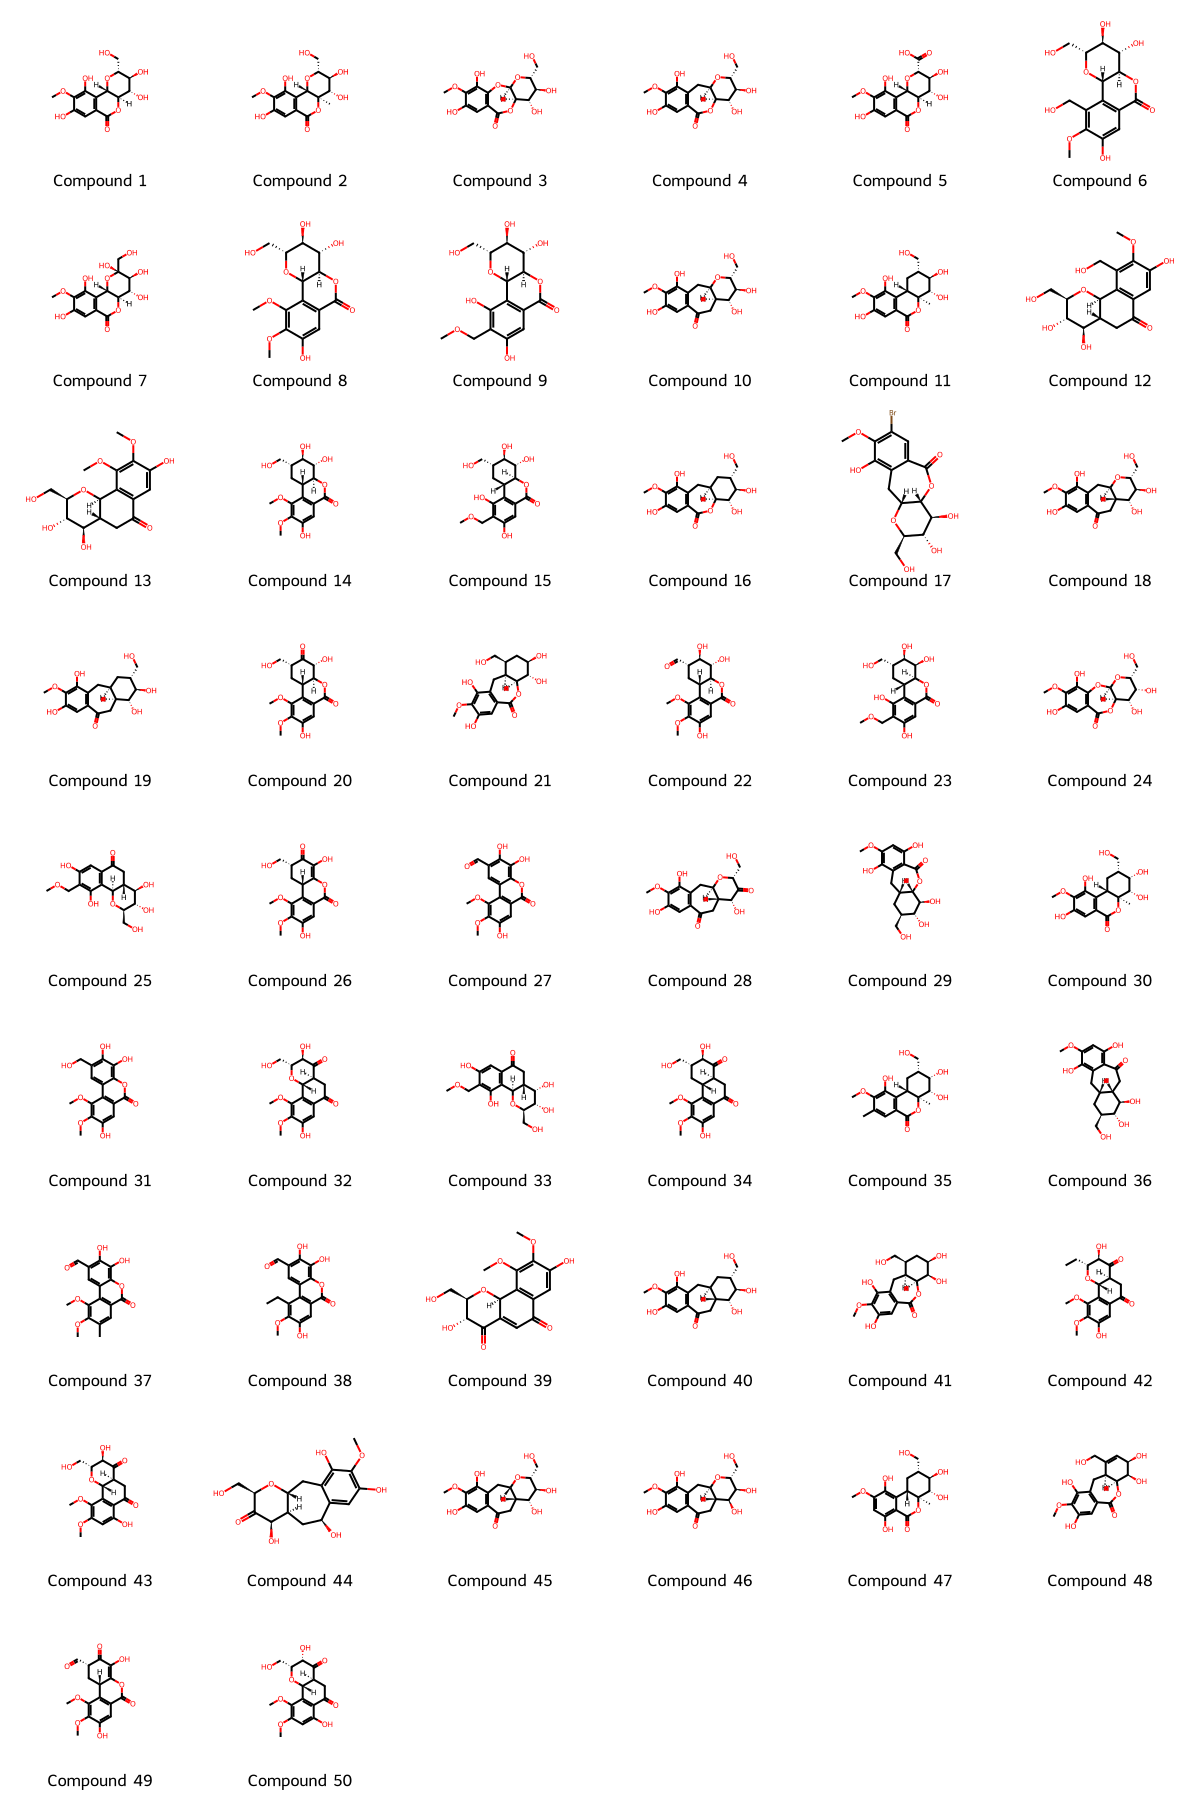

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdBase
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit import RDConfig
import os
sdf = Chem.SDMolSupplier("Evolutionary_Library_bergenin.sdf")
mols = [  m for m in sdf ]
img = Draw.MolsToGridImage( mols, molsPerRow=6, useSVG=True, legends=[x.GetProp("_Name") for x in mols[0:]])
img

In [ ]:
!pip3 install rdkit

  Using cached rdkit-2024.3.3-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (3.9 kB)
  Using cached pillow-10.4.0-cp310-cp310-manylinux_2_28_x86_64.whl.metadata (9.2 kB)
Using cached rdkit-2024.3.3-cp310-cp310-manylinux_2_28_x86_64.whl (33.1 MB)
Using cached pillow-10.4.0-cp310-cp310-manylinux_2_28_x86_64.whl (4.5 MB)


/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória


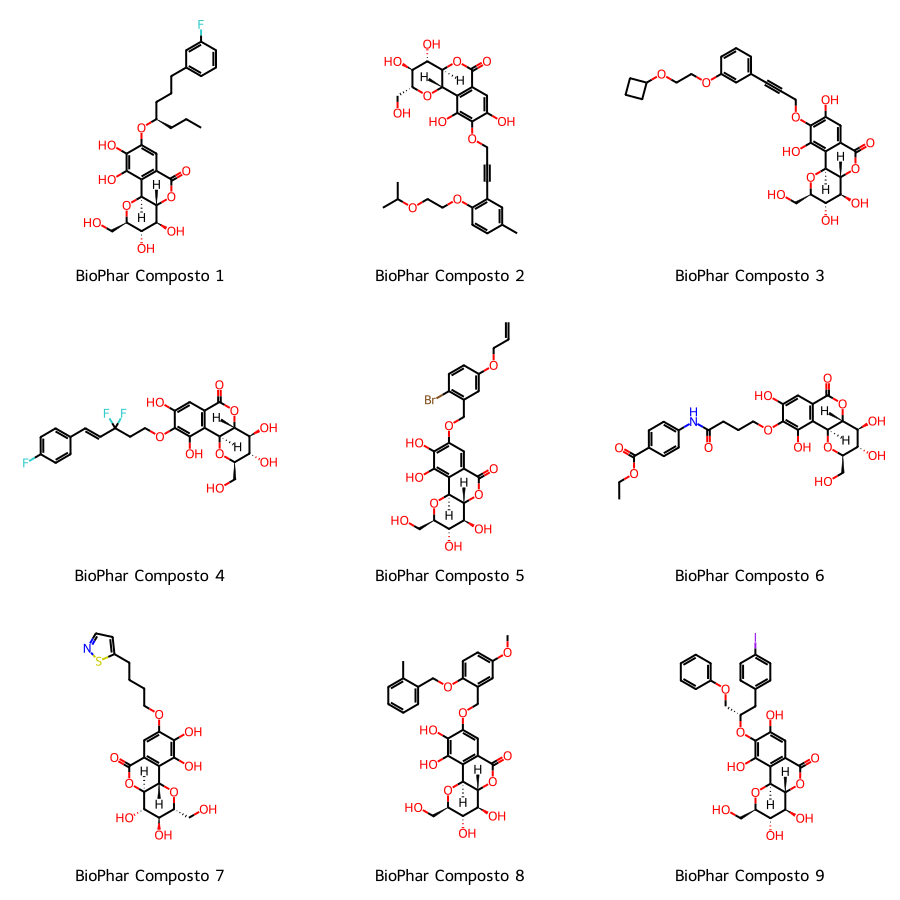

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdBase
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit import RDConfig
import os

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória

sdf = Chem.SDMolSupplier("best_screening_P2Y12_dockthor_maestro_nitrobenzene_enumeration.sdf")
mols = [  m for m in sdf ]
img = Draw.MolsToGridImage( mols, molsPerRow=3, useSVG=False, returnPNG=True, subImgSize=(400, 400), legends=[x.GetProp("_Name") for x in mols[0:]])
img


/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória


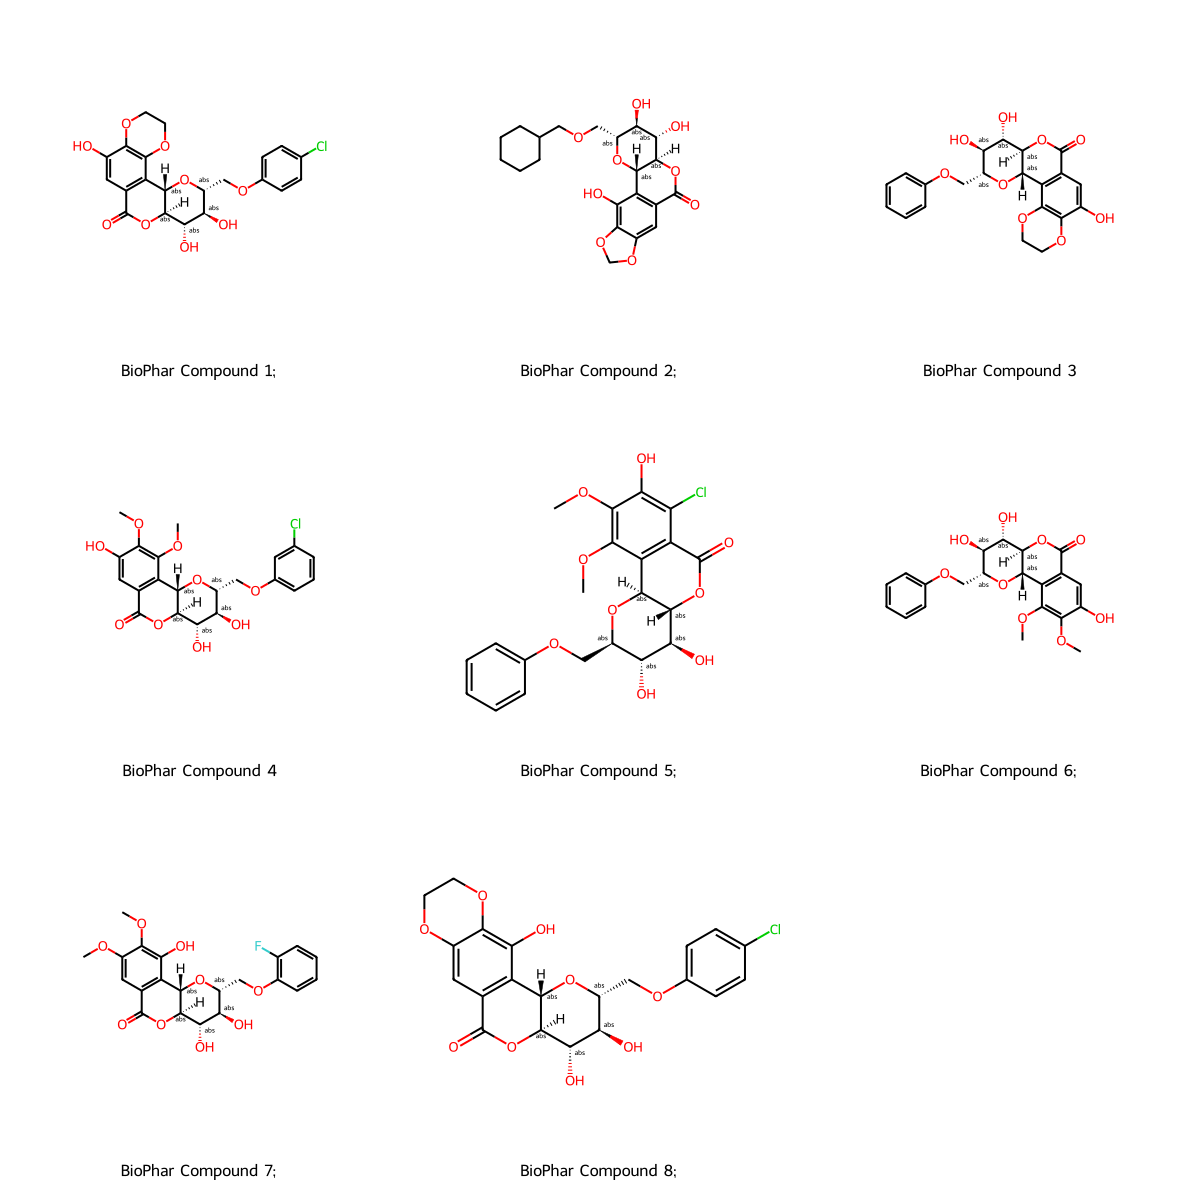

In [ ]:
from rdkit import Chem
from rdkit.Chem import rdBase
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
from rdkit import RDConfig
import os

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Química Combinatória

sdf = Chem.SDMolSupplier("screening_2d_conf_P2Y12_bergenin_derivates_AIDD_02_08_24.sdf")
mols = [  m for m in sdf ]
img = Draw.MolsToGridImage( mols, molsPerRow=3, useSVG=False, returnPNG=True, subImgSize=(400, 400), legends=[x.GetProp("_Name") for x in mols[0:]])
img


In [ ]:
from rdkit import Chem
from rdkit.Chem import rdMolDescriptors
from rdkit.Chem import Draw

# Load the molecules from the SDF file
sdf = Chem.SDMolSupplier("screening_2d_conf_P2Y12_bergenin_derivates_AIDD_02_08_24.sdf")
mols = [m for m in sdf if m is not None]

# Calculate molecular masses
molecular_masses = [rdMolDescriptors.CalcExactMolWt(m) for m in mols]

# Display molecular masses along with the images
legends = [f"{m.GetProp('_Name')}: {mass:.2f} g/mol" for m, mass in zip(mols, molecular_masses)]
img = Draw.MolsToGridImage(mols, molsPerRow=3, useSVG=False, returnPNG=True, subImgSize=(400, 400), legends=legends)
img


ModuleNotFoundError: No module named 'rdkit'

# Ensaios de agregação plaquetária

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Agregação plaquetária


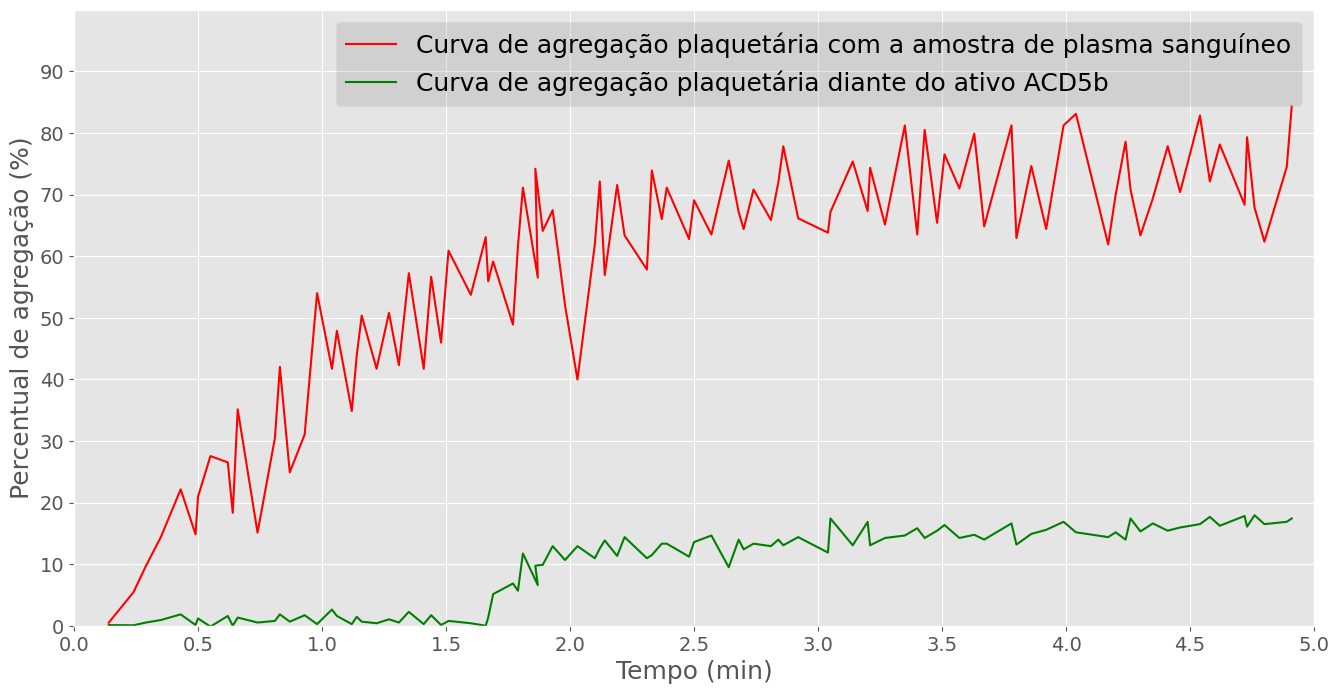

In [ ]:
#@title **Curva de agregação plaquetária para o derivado ACD5b**

import matplotlib.pyplot as plt
import pandas as pd

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Agregação plaquetária/

d1 = pd.read_csv('agregacao_plaquetaria_dados.csv', decimal='.')

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('ggplot')

fig = plt.figure(figsize=(16,8))
ax = plt.subplot(111)
ax.set_xticks(np.arange(0, 5.1, 0.5))
ax.set_yticks(np.arange(0, 100, 10))
#ax.grid(which='major', color='#CCCCCC', linestyle='--')
#ax.grid(which='minor', color='#CCCCCC', linestyle='--')
plt.xlim([0, 5])
plt.ylim([0, 100])
plt.plot(d1['Time_1'], d1['Agregation_plasma'], label='Curva de agregação plaquetária com a amostra de plasma sanguíneo', color='red')
plt.plot(d1['Time_1'], d1['Agregation_acd5b'], label='Curva de agregação plaquetária diante do ativo ACD5b', color='green')
#plt.plot(d2['X'], d2['Y']/(d2['Y'].max()), label='Espectro UV-Vis téorico da molecula ACD5b')
# A conversão de epsilon para absorbância requer o uso da Lei de Beer-Lambert, onde A = epsilon (M^{-1} . cm^-1) * l (cm) * c (mol/L)

plt.xlabel('Tempo (min)', fontsize=18)
plt.ylabel('Percentual de agregação (%)', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(facecolor="gray", framealpha=0.2, frameon=True, fontsize=18)
plt.savefig('curva_agregacao.png', dpi=300, bbox_inches = 'tight')

/content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Agregação plaquetária


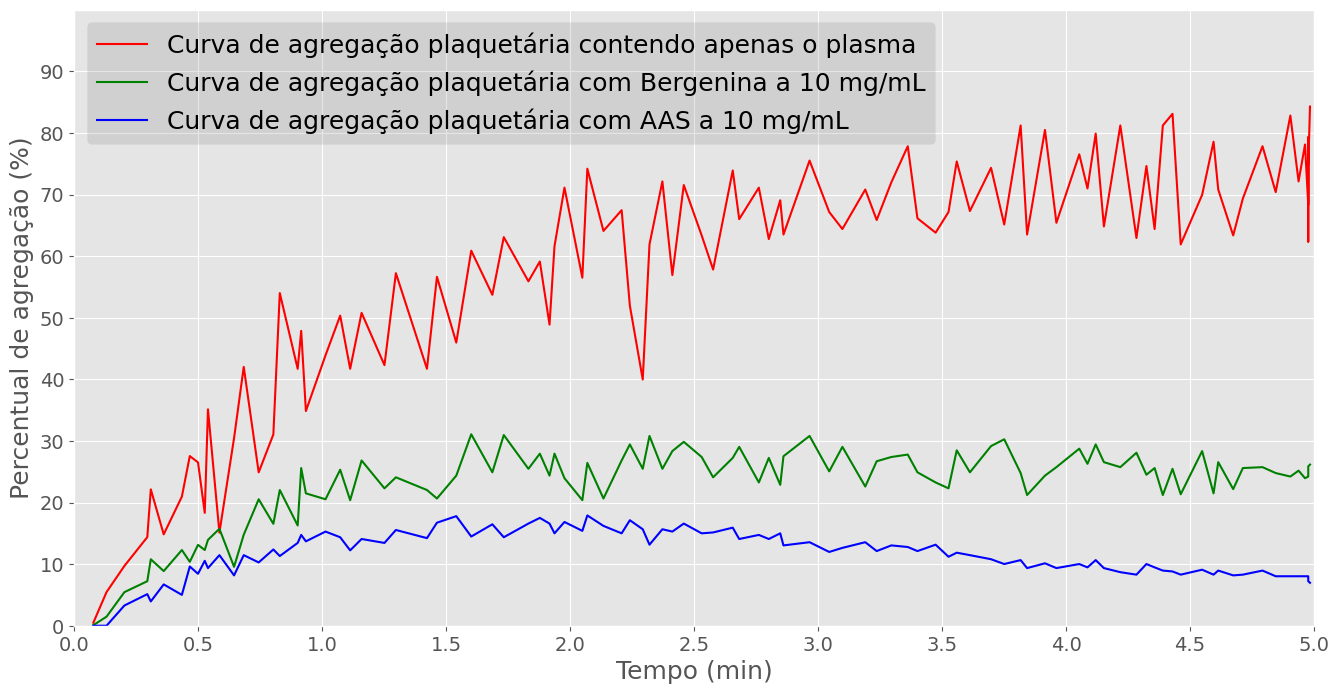

In [ ]:
#@title **Curva de agregação plaquetária para Bergenina**

import matplotlib.pyplot as plt
import pandas as pd

%cd /content/drive/MyDrive/Iniciação Científica/Pibic 2023-2024 (Neuropatia diabética)/Agregação plaquetária/

d1 = pd.read_csv('dados_agregacao_06_07_2023.csv', decimal='.')

import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline
plt.style.use('ggplot')

fig = plt.figure(figsize=(16,8))
ax = plt.subplot(111)
ax.set_xticks(np.arange(0, 5.1, 0.5))
ax.set_yticks(np.arange(0, 100, 10))
#ax.grid(which='major', color='#CCCCCC', linestyle='--')
#ax.grid(which='minor', color='#CCCCCC', linestyle='--')
plt.xlim([0, 5])
plt.ylim([0, 100])
plt.plot(d1['Tempo'], d1['Agregacao_plasma'], label='Curva de agregação plaquetária contendo apenas o plasma', color='red')
plt.plot(d1['Tempo'], d1['Agregacao_bergenina_10mg_ml'], label='Curva de agregação plaquetária com Bergenina a 10 mg/mL', color='green')
plt.plot(d1['Tempo'], d1['Agregacao_AAS_10mg.ml-1'], label='Curva de agregação plaquetária com AAS a 10 mg/mL', color='blue')
#plt.plot(d2['X'], d2['Y']/(d2['Y'].max()), label='Espectro UV-Vis téorico da molecula ACD5b')
# A conversão de epsilon para absorbância requer o uso da Lei de Beer-Lambert, onde A = epsilon (M^{-1} . cm^-1) * l (cm) * c (mol/L)

plt.xlabel('Tempo (min)', fontsize=18)
plt.ylabel('Percentual de agregação (%)', fontsize=18)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(facecolor="gray", framealpha=0.2, frameon=True, fontsize=18)
plt.savefig('curva_agregacao_bergenina.png', dpi=300, bbox_inches = 'tight')

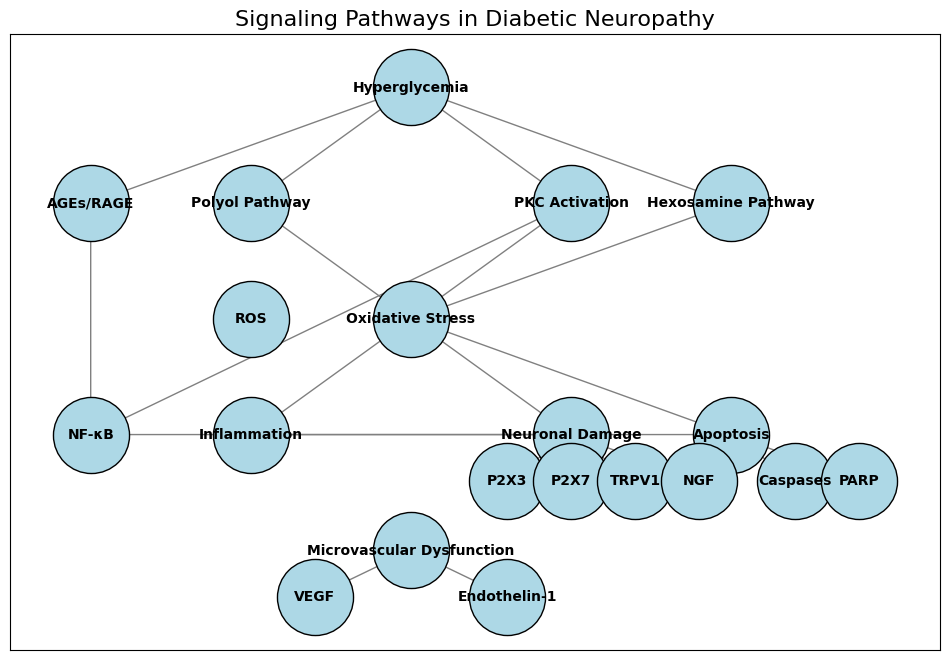

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt

# Create a directed graph
G = nx.DiGraph()

# Define nodes (pathway components)
pathway_components = [
    "Hyperglycemia",
    "AGEs/RAGE", "Polyol Pathway", "PKC Activation", "Hexosamine Pathway",
    "Oxidative Stress", "Inflammation", "Neuronal Damage", "Apoptosis", "Microvascular Dysfunction",
    "NF-κB", "ROS", "P2X3", "P2X7", "TRPV1", "NGF", "Caspases", "PARP", "VEGF", "Endothelin-1"
]

# Add nodes to the graph
G.add_nodes_from(pathway_components)

# Define edges (interactions between components)
edges = [
    ("Hyperglycemia", "AGEs/RAGE"),
    ("Hyperglycemia", "Polyol Pathway"),
    ("Hyperglycemia", "PKC Activation"),
    ("Hyperglycemia", "Hexosamine Pathway"),
    ("AGEs/RAGE", "NF-κB"),
    ("Polyol Pathway", "Oxidative Stress"),
    ("PKC Activation", "NF-κB"),
    ("PKC Activation", "Oxidative Stress"),
    ("Hexosamine Pathway", "Oxidative Stress"),
    ("Oxidative Stress", "Inflammation"),
    ("Oxidative Stress", "Neuronal Damage"),
    ("Oxidative Stress", "Apoptosis"),
    ("NF-κB", "Inflammation"),
    ("Inflammation", "Neuronal Damage"),
    ("Inflammation", "Apoptosis"),
    ("Neuronal Damage", "P2X3"),
    ("Neuronal Damage", "P2X7"),
    ("Neuronal Damage", "TRPV1"),
    ("Neuronal Damage", "NGF"),
    ("Apoptosis", "Caspases"),
    ("Apoptosis", "PARP"),
    ("Microvascular Dysfunction", "VEGF"),
    ("Microvascular Dysfunction", "Endothelin-1")
]

# Add edges to the graph
G.add_edges_from(edges)

# Set up the layout for the graph
pos = nx.spring_layout(G, seed=42)  # Use a fixed seed for reproducibility

# Manually adjust positions for better label placement
pos["Hyperglycemia"] = (0, 1)  # Center top
pos["AGEs/RAGE"] = (-1, 0.5)
pos["Polyol Pathway"] = (-0.5, 0.5)
pos["PKC Activation"] = (0.5, 0.5)
pos["Hexosamine Pathway"] = (1, 0.5)
pos["Oxidative Stress"] = (0, 0)
pos["NF-κB"] = (-1, -0.5)
pos["Inflammation"] = (-0.5, -0.5)
pos["Neuronal Damage"] = (0.5, -0.5)
pos["Apoptosis"] = (1, -0.5)
pos["Microvascular Dysfunction"] = (0, -1)
pos["ROS"] = (-0.5, 0)
pos["P2X3"] = (0.3, -0.7)
pos["P2X7"] = (0.5, -0.7)
pos["TRPV1"] = (0.7, -0.7)
pos["NGF"] = (0.9, -0.7)
pos["Caspases"] = (1.2, -0.7)
pos["PARP"] = (1.4, -0.7)
pos["VEGF"] = (-0.3, -1.2)
pos["Endothelin-1"] = (0.3, -1.2)

# Draw the graph
plt.figure(figsize=(12, 8))
nx.draw_networkx_nodes(G, pos, node_size=3000, node_color="lightblue", edgecolors="black")
nx.draw_networkx_edges(G, pos, arrowstyle="->", arrowsize=20, edge_color="gray")
nx.draw_networkx_labels(G, pos, font_size=10, font_weight="bold")

# Add a title
plt.title("Signaling Pathways in Diabetic Neuropathy", fontsize=16)

# Remove axes
plt.axis("on")

# Show the plot
plt.show()

#Protocolos de docking molecular no software GOLD v.2023-2

Serial para instalação: DE2CB0-3DA0D9-4E618A-6C2ACD-CB8C58-57C01F

Onde baixa o software GOLD: https://bdec.dotlib.com.br/

É necessário e-mail institucional para o cadastro

#Análises MM-GBSA



In [ ]:
$SCHRODINGER/run thermal_mmgbsa.py  xx-out.cms -j energy-calc -start_frame 4000 -end_frame 8000 -step_size 50 -HOST localhost:8 -NJOBS 8 > output

#Caderno de laboratório e progressos na pesquisa

---
**Dia 21 de setembro de 2024**

Nas análises de dinâmica molecular bem como na execução é fundamental que sejam
executadas na mesma versão do Schrodinger Maestro onde foi simulado e preparado.
Ao que percebi, a mais estável ainda é 2021-2.

**Dia 22 de setembro de 2024**

O comando que pode ser utilizado no Linux para acessar o Gaussian16 é:

g16 <molecule.gjf> molecule.log

# Escrita do artigo científico

O Fabiano sugeriu